<h1 style="text-align:center;">AF3 Motif Builder</h1>

In [1]:
import glob
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

# Build motif

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_86826/3186434303.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/{topdir}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]


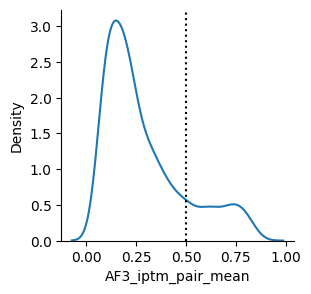

In [8]:
topdir = 'chainA_B_random_pair_LLWNGPMAV'
df = pd.read_csv(f'{topdir}/{topdir}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

fig, ax = plt.subplots(1, 1, figsize=(3,3))
sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
sns.despine()
ax.axvline(0.5, color='black', linestyle=':')

In [ ]:
# prepaire csv for motif building
topdir = 'step1_LLWNGPMAV'
df = pd.read_csv(f'{topdir}/{topdir}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
anno = pd.read_csv(f'{topdir}/{topdir}_input.txt', delim_whitespace=True)

df = pd.merge(df, anno, on='id')

baseline = df.copy()
baseline.to_csv(f'{topdir}/baseline.csv', index=False)

thresholds = [0.5, 0.7, 0.8, 0.9]

lst = []
for threshold in thresholds:
    tmp = df.copy()
    below = tmp[tmp['AF3_iptm_pair_mean'] < threshold]
    below['model'] = f'ipTM < {threshold}'
    lst.append(below)
    
    above = tmp[tmp['AF3_iptm_pair_mean'] > threshold]
    above['model'] = f'ipTM > {threshold}'
    lst.append(above)

df = pd.concat(lst)
df.to_csv(f'{topdir}/enrichment_by_ipTM.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_60023/1668833007.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/{topdir}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_60023/1668833007.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/{topdir}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_60023/1668833007.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
